# Notebook to check initial condition of dicotron instability

In [1]:
from params_dicotron import *
from struphy import PlottingData, PostProcessor

import os
import cunumpy as xp
from matplotlib import pyplot as plt

sim_path = os.path.join(os.getcwd(), "simdata")

pp = PostProcessor(path_out=sim_path)
pp.process()

pdata = PlottingData(path_out=sim_path)
pdata.load()


Reading in paramters from /home/local/struphy/struphy-parameter-files/ToyGyrokinetic/diocotron_instability/simdata ... 

Post-processing path /home/local/struphy/struphy-parameter-files/ToyGyrokinetic/diocotron_instability/simdata

Reading hdf5 data of following species:
em_fields:
  phi: <HDF5 dataset "phi": shape (2, 38, 70, 3), type "<f8">



100%|██████████| 1/1 [00:00<00:00, 713.68it/s]


Creation of Struphy Fields done.

Evaluating fields ...


100%|██████████| 2/2 [00:00<00:00, 112.83it/s]



Creating vtk in /home/local/struphy/struphy-parameter-files/ToyGyrokinetic/diocotron_instability/simdata/post_processing/fields_data ...


...

Evaluation of 3 marker orbits for kinetic_ions


100%|██████████| 2/2 [00:00<00:00, 248.54it/s]


Evaluation of distribution functions for kinetic_ions


100%|██████████| 1/1 [00:00<00:00, 90.73it/s]


Loading post-processed plotting data:
Data path: /home/local/struphy/struphy-parameter-files/ToyGyrokinetic/diocotron_instability/simdata/post_processing

Files in /home/local/struphy/struphy-parameter-files/ToyGyrokinetic/diocotron_instability/simdata/post_processing/fields_data/em_fields: ['phi_log.bin']

The following data has been loaded:

grids:
self.t_grid.shape =(2,)
self.grids_log[0].shape =(129,)
self.grids_log[1].shape =(129,)
self.grids_log[2].shape =(2,)
self.grids_phy[0].shape =(129, 129, 2)
self.grids_phy[1].shape =(129, 129, 2)
self.grids_phy[2].shape =(129, 129, 2)

self.spline_values:
    em_fields
        phi_log

self.orbits:
    kinetic_ions, shape = (2, 3, 8)
        Number of time points: 2
        Number of particles:   3
        Number of attributes:  8

self.f:
    kinetic_ions
        e1_e2_density

self.n_sph:



In [19]:
# useful transformation functions
transform_x = lambda eta1, eta2, poc: ( a1+(a2-a1)*eta1 ) * xp.cos(2*xp.pi*eta2/poc)
transform_y = lambda eta1, eta2, poc: ( a1+(a2-a1)*eta1 ) * xp.sin(2*xp.pi*eta2/poc)

transform_r = lambda x, y: xp.sqrt(x**2 + y**2)
transform_theta = lambda x, y: xp.arctan(y/x)


# Transform logical space to cartesian then polar coordinate
domain_params = domain.params
a1 = domain_params["a1"]
a2 = domain_params["a2"]
Lz = domain_params["Lz"]
poc = domain_params["poc"]

def logical_to_cylindrical(eta1,eta2,eta3):
    x = transform_x(eta1,eta2,poc)
    y = transform_y(eta1,eta2,poc)

    r = transform_r(x,y)
    theta = transform_theta(x,y)
    z = Lz * eta3
    
    return r, theta, z

# these funcitons can be by passed with pdata.grids_phys e.g. to determine physical grid of r
r = pdata.grids_phy[0][:,0,0]


# Check simulation domain

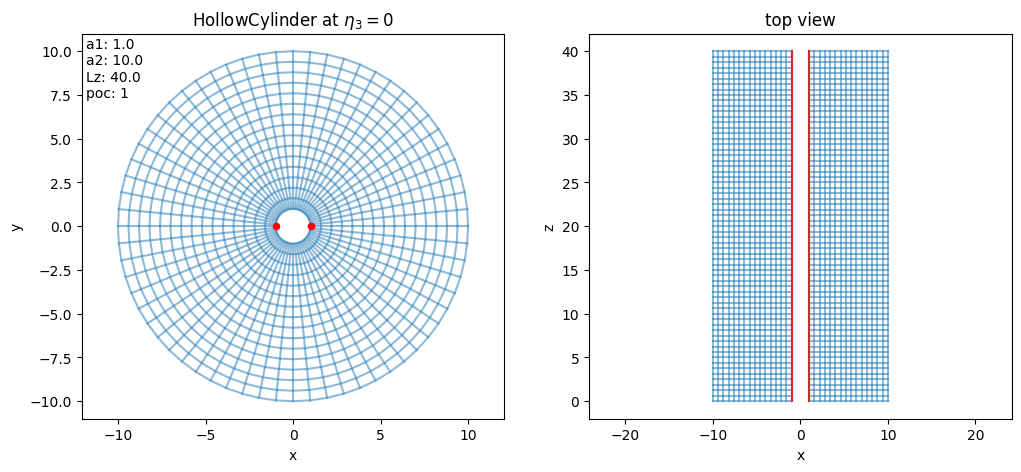

In [178]:
domain.show()

# Check initial electric potential

/tmp/ipykernel_18005/639694146.py:31: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax[1].pcolormesh(R, Theta, init_phi[0][:,:,0], cmap = "Purples")


Text(0.5, 1.0, 'Cylindrical coordinate')

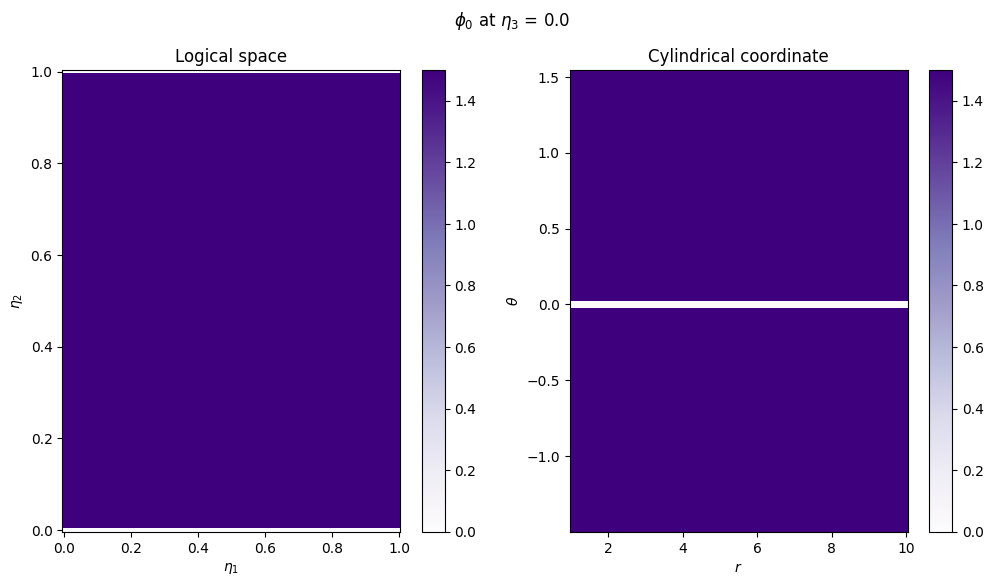

In [179]:
# create figure to show boundary conditions
fig, ax = plt.subplots(ncols = 2, figsize = (12,6))
fig.suptitle(rf"$\phi_0$ at $\eta_3$ = {pdata.grids_log[2][0]}");

# determine boundary condition in logical coordinate
init_phi = pdata.spline_values.em_fields.phi_log.data[0.0]
init_phi[0][0,0,0]

eta1 = pdata.grids_log[0]
eta2 = pdata.grids_log[1]
Eta1, Eta2 = xp.meshgrid(eta1,eta2)

# show boundary condition in logical space
pcm = ax[0].pcolormesh(Eta1,Eta2,init_phi[0][:,:,0], cmap="Purples")
fig.colorbar(pcm, ax = ax[0])
ax[0].set_xlabel(r"$\eta_1$")
ax[0].set_ylabel(r"$\eta_2$")
ax[0].set_title("Logical space")

# determine boundary condiiton in cylindrical coordinate

x = transform_x(eta1, eta2, poc)
y = transform_y(eta1, eta2, poc)

r = xp.sqrt(x**2 + y**2)
theta = xp.arctan(y/x)

# create heatmap from cylindrical coordinate
R, Theta = xp.meshgrid(r,theta)

pcm = ax[1].pcolormesh(R, Theta, init_phi[0][:,:,0], cmap = "Purples")
fig.colorbar(pcm, ax = ax[1])

ax[1].set_xlabel(r"$r$")
ax[1].set_ylabel(r"$\theta$");
ax[1].set_title("Cylindrical coordinate")

From the above plot, we see that the initial electric potentail $\phi_0$ is uniform except at the boundary of $\eta_2$. This is preferred as specified in the Dirichlet boundary condition. 

However, when the coordinate is transformed to the cylindrical coordinate we see that the 0 value lies at the minimum and maximum of theta instead of the intentional r. This must be further addressed

# Check initial mass density distribution

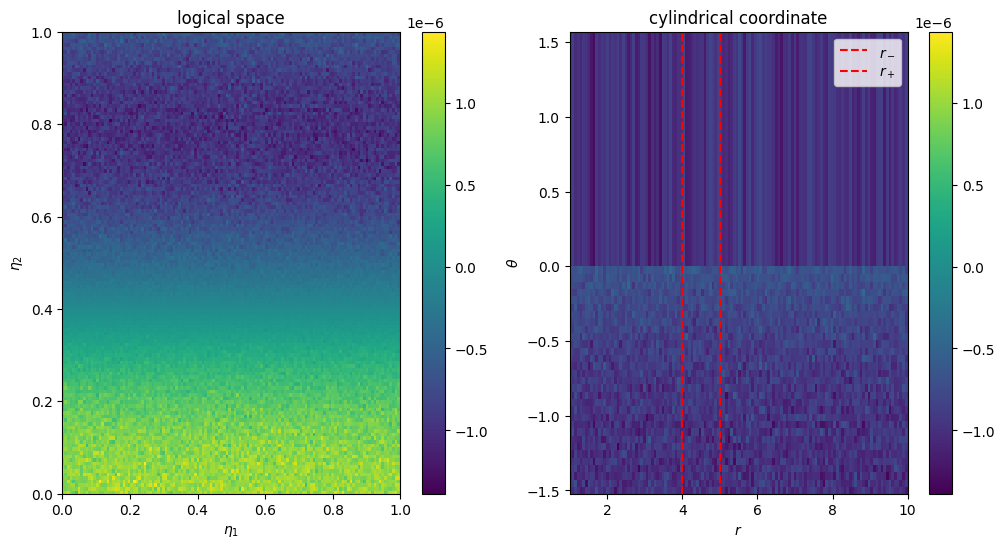

In [6]:
bin1 = pdata.f.kinetic_ions.e1_e2_density.grid_e1
bin2 = pdata.f.kinetic_ions.e1_e2_density.grid_e2

color_mapped = pdata.f.kinetic_ions.e1_e2_density.f_binned[0].T

fig, ax = plt.subplots(ncols = 2, figsize = (12,6))

# logical space
pcm = ax[0].pcolor(bin1,bin2,color_mapped)
fig.colorbar(pcm, ax=ax[0])
ax[0].set_xlabel(r"$\eta_1$")
ax[0].set_ylabel(r"$\eta_2$")
ax[0].set_title("logical space");

# cylindrical coordinate
r, theta, z = logical_to_cylindrical(*pdata.grids_log)

pcm = ax[1].pcolor(r,theta,color_mapped)
ax[1].set_xlabel(r"$r$")
ax[1].set_ylabel(r"$\theta$")
ax[1].set_title("cylindrical coordinate")

fig.colorbar(pcm, ax=ax[1])

ax[1].axvline(r_minus, ls = "--", color = "red", label = r"$r_-$")
ax[1].axvline(r_plus, ls = "--", color = "red", label = r"$r_+$")
ax[1].legend(loc = "upper right")